## Figures for Chemical Science manuscript

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sys
from scipy.stats import pearsonr, kendalltau
from sklearn.metrics import mean_squared_error

In [2]:
import matplotlib as mpl
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['font.size'] = 10

### Main paper

#### Figure 1: AEV radial components

In [3]:
def cutoff_fn_ANI(x, Rc):
    return 0.5 * np.cos(np.pi * (x / Rc)) + 0.5

def radial_ANI(x, Rc, Eta, Rs):
    return np.exp(-Eta * (x - Rs)**2) * cutoff_fn_ANI(x, Rc)

RcR = 5.1  # Radial cutoff
EtaR = 19.7  # Radial decay
RsR_vec = [0.80, 1.34, 1.88, 2.41, 2.95, 3.49, 4.03, 4.56]  # Radial shift

def plot_radial_aevs(RcR, EtaR, RsR_vec, outpath=None):
    
    R = np.arange(0, RcR + 0.01, 0.01)
    data = {'R': R}

    for RsR in RsR_vec:
        col_name = f"{RsR:.2f}"
        data[col_name] = radial_ANI(R, RcR, EtaR, RsR)

    data_long = pd.melt(pd.DataFrame(data), id_vars='R', var_name='Center', value_name='value')

    plt.figure(figsize=(6, 3))

    sns.lineplot(data=data_long, x='R', y='value', hue='Center', linewidth=1.5)

    plt.ylabel(r'$C(R_{ij})$')
    plt.xlabel(r'$R_{ij}\ (\AA)$')
    plt.legend(title=r"R$_s$ ($\AA$)", title_fontsize='10', fontsize='9', frameon=False)

    if outpath:
        plt.savefig(outpath, bbox_inches='tight')

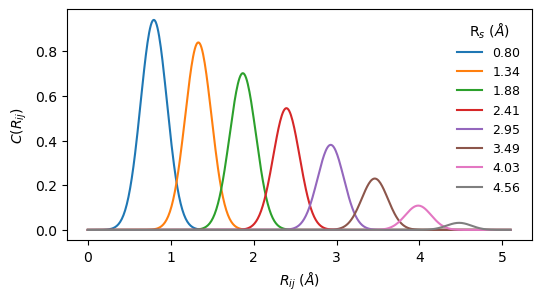

In [4]:
plot_radial_aevs(RcR, EtaR, RsR_vec, outpath='figure1.pdf')

#### Figure 2: AEV-PLIG model schematic

Created separately.

#### Figure 3: AEV-PLIG baseline performance

In [5]:
def rmse(true, pred):
    return np.sqrt(mean_squared_error(true, pred))

def pk_to_dg(pk):
    """ Convert pK to free energy in kcal/mol."""
    r = 8.3145  # J/mol/K
    t = 297  # K
    k = 10**-pk
    dg_j = r * t * np.log(k)  # Natural log
    dg_kcal = dg_j / 4184

    return dg_kcal

def format_marginal(ax, horizontal=True):

        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if horizontal:
            ax.spines['left'].set_visible(False)
            ax.invert_xaxis()
            
        else:
            ax.spines['bottom'].set_visible(False)
            ax.invert_yaxis()

        ax.set_ylabel('')
        ax.set_xlabel('')

def plot_scatter_with_marginals(df1, df2, x_col, y_col, group_col, outpath=None):

    fig = plt.figure(figsize=(4, 7), constrained_layout=True)

    widths = [4, 0.6]
    heights = [0.6, 4, 0.6, 4]
    lims = [-16, -2]

    spec = fig.add_gridspec(ncols=2, nrows=4, width_ratios=widths,
                        height_ratios=heights)
    
    # Dotted x=y line
    ax1 = fig.add_subplot(spec[1, 0])
    ax1.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    ax2 = fig.add_subplot(spec[3, 0])
    ax2.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    # Scatter plots
    sns.scatterplot(data=df1, x=x_col, y=y_col, color='darkorange', ax=ax1, legend=False, edgecolor='black', alpha=0.6, zorder=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_xlabel('')
    ax1.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax1.set_xticks([-16,-12,-8,-4])

    sns.scatterplot(data=df2, x=x_col, y=y_col, color='forestgreen', ax=ax2, legend=False,  edgecolor='black', alpha=0.6, zorder=10)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xlabel(r'Exp. $\Delta$G (kcal/mol)')
    ax2.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax2.set_xticks(np.arange(lims[0],lims[1],-2))
    ax2.set_xticks([-16,-12,-8,-4])

    # Marginal histograms (remove labels, ticks and boxes)
    ax1_marg_x = fig.add_subplot(spec[0, 0])
    sns.kdeplot(data=df1, x=x_col, color='darkorange', ax=ax1_marg_x, legend=False)
    format_marginal(ax1_marg_x)
    ax1_marg_x.set_xlim(lims)
    
    ax1_marg_y = fig.add_subplot(spec[1, 1])
    sns.kdeplot(data=df1, y=y_col, color='darkorange', ax=ax1_marg_y, legend=False)
    format_marginal(ax1_marg_y, horizontal=False)
    ax1_marg_y.set_ylim(lims)

    ax2_marg_x = fig.add_subplot(spec[2, 0])
    sns.kdeplot(data=df2, x=x_col, color='forestgreen', ax=ax2_marg_x, legend=False)
    format_marginal(ax2_marg_x)
    ax2_marg_x.set_xlim(lims)

    ax2_marg_y = fig.add_subplot(spec[3, 1])
    sns.kdeplot(data=df2, y=y_col, color='forestgreen', ax=ax2_marg_y, legend=False)
    format_marginal(ax2_marg_y, horizontal=False)
    ax2_marg_y.set_ylim(lims)

    # Annotations
    ax1.set_title('a)', loc='left', position=(-0.2, 1.0), fontsize=12)
    ax2.set_title('b)', loc='left', position=(-0.2, 1.0), fontsize=12)

    ax1_pcc, ax1_kt, ax1_rmse = pearsonr(df1[x_col], df1[y_col])[0], kendalltau(df1[x_col], df1[y_col])[0], rmse(df1[x_col], df1[y_col])
    ax2_pcc, ax2_kt, ax2_rmse = pearsonr(df2[x_col], df2[y_col])[0], kendalltau(df2[x_col], df2[y_col])[0], rmse(df2[x_col], df2[y_col])
    ax1.text(-16, -4, f'PCC = {ax1_pcc:.2f}\n'+r'K$\tau$ = '+f'{ax1_kt:.2f}\nRMSE = {ax1_rmse:.2f}', fontsize=9)
    ax2.text(-16, -4, f'PCC = {ax2_pcc:.2f}\n'+r'K$\tau$ = '+f'{ax2_kt:.2f}\nRMSE = {ax2_rmse:.2f}', fontsize=9)

    if outpath:
        plt.tight_layout(w_pad=1, h_pad=0)
        plt.savefig(outpath, bbox_inches='tight')

In [6]:
ood_baseline_predictions = pd.read_csv("../data/baseline/ood_test_refined+_predictions.csv")
ood_baseline_predictions.rename(columns={'preds': 'preds_pk'}, inplace=True)
ood_baseline_predictions['Exp. ΔG'] = [pk_to_dg(pk) for pk in ood_baseline_predictions['truth']]
ood_baseline_predictions['preds'] = [pk_to_dg(pk) for pk in ood_baseline_predictions['preds_pk']]
ood_baseline_predictions['Target'] = 'OOD'

casf16_baseline_predictions = pd.read_csv("../data/baseline/casf2016_pdbbind_predictions.csv")
casf16_baseline_predictions.rename(columns={'preds': 'preds_pk'}, inplace=True)
casf16_baseline_predictions['Exp. ΔG'] = [pk_to_dg(pk) for pk in casf16_baseline_predictions['truth']]
casf16_baseline_predictions['preds'] = [pk_to_dg(pk) for pk in casf16_baseline_predictions['preds_pk']]
casf16_baseline_predictions['Target'] = 'CASF2016'

/var/folders/n0/jnvj1pls2_5_j5b80078qmx40000gn/T/ipykernel_74614/3378563848.py:97: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout(w_pad=1, h_pad=0)


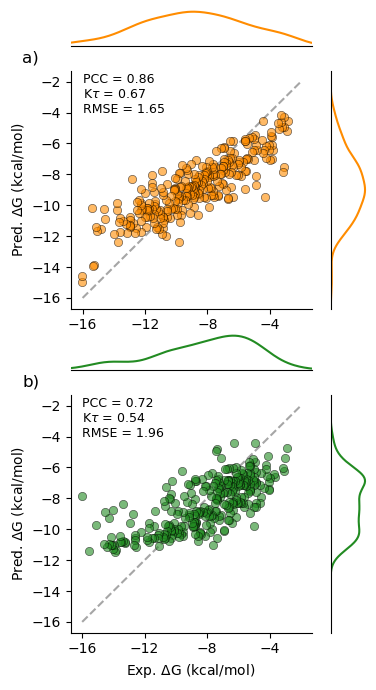

In [7]:
plot_scatter_with_marginals(casf16_baseline_predictions,ood_baseline_predictions, 'Exp. ΔG', 'preds', 'Target', './figure3.pdf')

#### Figure 4: AEV-PLIG performance and training set similarity

In [8]:
def weighted_pearson(preds, truth, target):

    results = pd.DataFrame(data={"preds": preds, "truth": truth, "target": target})
    targets = list(range(8))
    logs = []
    for target in targets:
        try:
            subset = results[results["target"] == target]
            logs.append(
                [target, pearsonr(subset["preds"], subset["truth"])[0], len(subset)]
            )
        except RuntimeWarning:
            pass
    performance = pd.DataFrame(logs, columns=["Target", "Pearson's R", "Sample size"])
    return np.average(performance["Pearson's R"], weights=performance["Sample size"])


def weighted_kendall(preds, truth, target):
    results = pd.DataFrame(data={"preds": preds, "truth": truth, "target": target})
    targets = list(range(8))
    logs = []
    for target in targets:
        subset = results[results["target"] == target]
        kendall = kendalltau(subset["preds"], subset["truth"])[0]
        if np.isnan(kendall):
            pass
        else:
            logs.append([target, kendall, len(subset)])

    performance = pd.DataFrame(logs, columns=["Target", "Kendall", "Sample size"])
    return np.average(performance["Kendall"], weights=performance["Sample size"])


def weighted_rmse(preds, truth, target):
    results = pd.DataFrame(data={"preds": preds, "truth": truth, "target": target})
    targets = list(range(8))
    logs = []
    for target in targets:
        subset = results[results["target"] == target]
        if len(subset) == 0:
            pass
        else:
            logs.append([target, rmse(subset["preds"], subset["truth"]), len(subset)])

    performance = pd.DataFrame(logs, columns=["Target", "RMSE", "Sample size"])
    return np.average(performance["RMSE"], weights=performance["Sample size"])


def get_weighted_stats_short(results, preds_col, truth_col, targets):
    results["pred"] = results[preds_col]
    results["truth"] = results[truth_col]

    logs = []
    for target in targets:
        subset = results[results["Target"] == target]
        logs.append(
            [
                target,
                pearsonr(subset["pred"], subset["truth"])[0],
                kendalltau(subset["pred"], subset["truth"])[0],
                rmse(subset["pred"], subset["truth"]),
                len(subset),
            ]
        )

    performance = pd.DataFrame(
        logs, columns=["Target", "Pearson's R", "Kendall's Tau", "RMSE", "Sample size"]
    )

    wpcc = np.average(performance["Pearson's R"], weights=performance["Sample size"])
    wktau = np.average(performance["Kendall's Tau"], weights=performance["Sample size"])
    wrmse = np.average(performance["RMSE"], weights=performance["Sample size"])

    return wpcc, wktau, wrmse

def plot_lineplot(
    x,
    y1,
    y2,
    y1_label,
    y2_label,
    y1_baseline,
    y2_baseline,
    y1_baseline_label,
    y2_baseline_label,
    y1_lims,
    y2_lims,
    y1_ticks,
    y2_ticks,
    xlabel,
    invert_xaxis=False,
    outpath=None,
):
    y1_color = "steelblue"
    y2_color = "firebrick"

    fig = plt.figure(figsize=(3.8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)

    # plot bindingnet data
    sns.lineplot(
        x=x,
        y=y1[0],
        label=y1_label,
        color=y1_color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax1,
    )
    sns.lineplot(
        x=x,
        y=y2[0],
        label=y2_label,
        color=y2_color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax1,
    )

    sns.lineplot(
        x=x,
        y=y1[1],
        color=y1_color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax2,
        legend=False,
    )
    sns.lineplot(
        x=x,
        y=y2[1],
        color=y2_color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax2,
        legend=False,
    )

    # plot baseline data
    sns.lineplot(
        x=x,
        y=y1_baseline[0],
        label=y1_baseline_label,
        color=y1_color,
        marker="^",
        linestyle="--",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax1,
    )
    sns.lineplot(
        x=x,
        y=y2_baseline[0],
        label=y2_baseline_label,
        color=y2_color,
        marker="^",
        linestyle="--",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax1,
    )

    sns.lineplot(
        x=x,
        y=y1_baseline[1],
        color=y1_color,
        marker="^",
        linestyle="--",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax2,
        legend=False,
    )
    sns.lineplot(
        x=x,
        y=y2_baseline[1],
        color=y2_color,
        marker="^",
        linestyle="--",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax2,
        legend=False,
    )

    ax1.set_ylabel("Weighted mean PCC")
    ax1.set_ylim(y1_lims)
    if invert_xaxis:
        ax1.invert_xaxis()
    ax1.set_yticks(y1_ticks)
    ax1.set_title("a)", loc="left", fontsize=14, position=(-0.25, 1.0))

    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(r"Weighted mean K$\tau$")
    ax2.set_ylim(y2_lims)
    ax2.set_xticks(x)
    ax2.set_yticks(y2_ticks)
    ax2.set_title("b)", loc="left", fontsize=14, position=(-0.25, 1.0))

    ax1.legend(bbox_to_anchor=(0.5, 1.25), loc="center", frameon=False)

    plt.tight_layout()

    if outpath:
        plt.savefig(outpath)

In [9]:
# Load results Schrodinger
results = pd.read_csv('../data/baseline/schrodinger_pdbbind_fep_predictions.csv')
schro_baseline_wpcc, schro_baseline_wktau, schro_baseline_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/baseline/schrodinger_pdbbind_ligsim90_predictions.csv')
schro_baseline_ls90_wpcc, schro_baseline_ls90_wktau, schro_baseline_ls90_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/baseline/schrodinger_pdbbind_ligsim90_predictions.csv')
schro_baseline_ls80_wpcc, schro_baseline_ls80_wktau, schro_baseline_ls80_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/baseline/schrodinger_pdbbind_ligsim70_predictions.csv')
schro_baseline_ls70_wpcc, schro_baseline_ls70_wktau, schro_baseline_ls70_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/baseline/schrodinger_pdbbind_ligsim60_predictions.csv')
schro_baseline_ls60_wpcc, schro_baseline_ls60_wktau, schro_baseline_ls60_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])

results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_fep_predictions.csv')
schro_bindingnet_wpcc, schro_bindingnet_wktau, schro_bindingnet_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim90_predictions.csv')
schro_bindingnet_ls90_wpcc, schro_bindingnet_ls90_wktau, schro_bindingnet_ls90_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim80_predictions.csv')
schro_bindingnet_ls80_wpcc, schro_bindingnet_ls80_wktau, schro_bindingnet_ls80_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim70_predictions.csv')
schro_bindingnet_ls70_wpcc, schro_bindingnet_ls70_wktau, schro_bindingnet_ls70_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_noligsim_predictions.csv')
schro_bindingnet_ls60_wpcc, schro_bindingnet_ls60_wktau, schro_bindingnet_ls60_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])

# Load results Merck
results = pd.read_csv('../data/baseline/merck_pdbbind_fep_predictions.csv')
merck_baseline_wpcc, merck_baseline_wktau, merck_baseline_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/baseline/merck_pdbbind_ligsim90_predictions.csv')
merck_baseline_ls90_wpcc, merck_baseline_ls90_wktau, merck_baseline_ls90_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/baseline/merck_pdbbind_ligsim90_predictions.csv')
merck_baseline_ls80_wpcc, merck_baseline_ls80_wktau, merck_baseline_ls80_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/baseline/merck_pdbbind_ligsim70_predictions.csv')
merck_baseline_ls70_wpcc, merck_baseline_ls70_wktau, merck_baseline_ls70_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/baseline/merck_pdbbind_ligsim60_predictions.csv')
merck_baseline_ls60_wpcc, merck_baseline_ls60_wktau, merck_baseline_ls60_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])

results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_fep_predictions.csv')
merck_bindingnet_wpcc, merck_bindingnet_wktau, merck_bindingnet_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim90_predictions.csv')
merck_bindingnet_ls90_wpcc, merck_bindingnet_ls90_wktau, merck_bindingnet_ls90_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim80_predictions.csv')
merck_bindingnet_ls80_wpcc, merck_bindingnet_ls80_wktau, merck_bindingnet_ls80_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim70_predictions.csv')
merck_bindingnet_ls70_wpcc, merck_bindingnet_ls70_wktau, merck_bindingnet_ls70_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_noligsim_predictions.csv')
merck_bindingnet_ls60_wpcc, merck_bindingnet_ls60_wktau, merck_bindingnet_ls60_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])

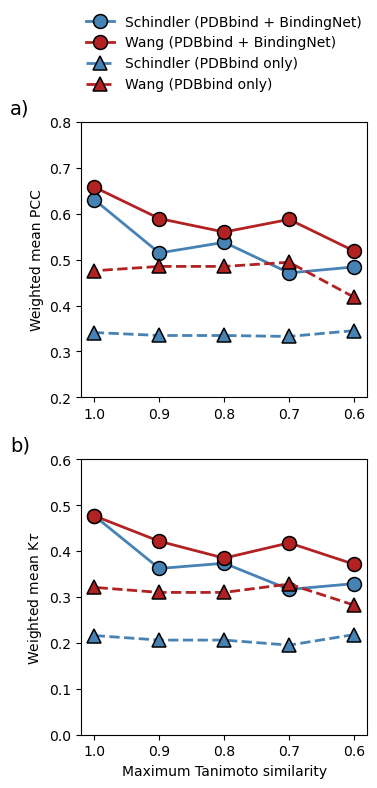

In [10]:
plot_lineplot(
    [1.0, 0.9, 0.8, 0.7, 0.6],
    [[merck_bindingnet_wpcc, merck_bindingnet_ls90_wpcc, merck_bindingnet_ls80_wpcc, merck_bindingnet_ls70_wpcc, merck_bindingnet_ls60_wpcc], [merck_bindingnet_wktau, merck_bindingnet_ls90_wktau, merck_bindingnet_ls80_wktau, merck_bindingnet_ls70_wktau, merck_bindingnet_ls60_wktau]],
    [[schro_bindingnet_wpcc, schro_bindingnet_ls90_wpcc, schro_bindingnet_ls80_wpcc, schro_bindingnet_ls70_wpcc, schro_bindingnet_ls60_wpcc], [schro_bindingnet_wktau, schro_bindingnet_ls90_wktau, schro_bindingnet_ls80_wktau, schro_bindingnet_ls70_wktau, schro_bindingnet_ls60_wktau]],
     "Schindler (PDBbind + BindingNet)", "Wang (PDBbind + BindingNet)",
    [[merck_baseline_wpcc, merck_baseline_ls90_wpcc, merck_baseline_ls80_wpcc, merck_baseline_ls70_wpcc, merck_baseline_ls60_wpcc], [merck_baseline_wktau, merck_baseline_ls90_wktau, merck_baseline_ls80_wktau, merck_baseline_ls70_wktau, merck_baseline_ls60_wktau]],
    [[schro_baseline_wpcc, schro_baseline_ls90_wpcc, schro_baseline_ls80_wpcc, schro_baseline_ls70_wpcc, schro_baseline_ls60_wpcc], [schro_baseline_wktau, schro_baseline_ls90_wktau, schro_baseline_ls80_wktau, schro_baseline_ls70_wktau, schro_baseline_ls60_wktau]],
    "Schindler (PDBbind only)", "Wang (PDBbind only)",
    [0.2, 0.8],
    [0.0, 0.6],
    [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    xlabel="Maximum Tanimoto similarity",
    invert_xaxis=True,
    outpath="figure4.pdf",
    )

#### Figure 5: Enriched AEV-PLIG performance

In [15]:
def plot_lineplot_with_error_bars(
    data_merck,
    data_schro,
    y1_label,
    y2_label,
    y1_baseline,
    y2_baseline,
    y1_baseline_label,
    y2_baseline_label,
    y1_lims,
    y2_lims,
    y1_ticks,
    y2_ticks,
    xlabel,
    invert_xaxis=False,
    outpath=None,
):
    y1_color = "steelblue"
    y2_color = "firebrick"

    fig = plt.figure(figsize=(3.8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)

    ax1.axhline(
        y=y1_baseline[0], color=y1_color, linestyle="--", label=y1_baseline_label, lw=2
    )
    ax1.axhline(
        y=y2_baseline[0], color=y2_color, linestyle="--", label=y2_baseline_label, lw=2
    )

    ax2.axhline(y=y1_baseline[1], color=y1_color, linestyle="--", lw=2)
    ax2.axhline(y=y2_baseline[1], color=y2_color, linestyle="--", lw=2)

    sns.lineplot(
        data = data_merck,
        x="Enrichment",
        y="WPCC",
        label=y1_label,
        color=y1_color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        errorbar="sd",
        err_style="bars",
        err_kws={"capsize":4,"elinewidth":1.5,"capthick":1.5,"ecolor":"steelblue","zorder":0},
        ax=ax1
    )

    sns.lineplot(
        data = data_schro,
        x="Enrichment",
        y="WPCC",
        label=y2_label,
        color=y2_color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        errorbar="sd",
        err_style="bars",
        err_kws={"capsize":4,"elinewidth":1.5,"capthick":1.5,"ecolor":"firebrick","zorder":0},
        ax=ax1,
    )

    sns.lineplot(
        data = data_merck,
        x="Enrichment",
        y="WKtau",
        color=y1_color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        errorbar="sd",
        err_style="bars",
        err_kws={"capsize":4,"elinewidth":1.5,"capthick":1.5,"ecolor":"steelblue","zorder":0},
        ax=ax2,
        legend=False,
    )

    sns.lineplot(
        data = data_schro,
        x="Enrichment",
        y="WKtau",
        color=y2_color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        errorbar="sd",
        err_style="bars",
        err_kws={"capsize":4,"elinewidth":1.5,"capthick":1.5,"ecolor":"firebrick","zorder":0},
        ax=ax2,
        legend=False,
    )

    ax1.set_ylabel("Weighted mean PCC")
    ax1.set_xlabel("")
    ax1.set_ylim(y1_lims)
    if invert_xaxis:
        ax1.invert_xaxis()
    ax1.set_yticks(y1_ticks)
    ax1.set_xticks([0,1,2,3,4,5,6])
    ax1.set_title("a)", loc="left", fontsize=14, position=(-0.25, 1.0))

    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(r"Weighted mean K$\tau$")
    ax2.set_ylim(y2_lims)
    ax2.set_yticks(y2_ticks)
    ax2.set_xticks([0,1,2,3,4,5,6])
    ax2.set_title("b)", loc="left", fontsize=14, position=(-0.25, 1.0))

    ax1.legend(bbox_to_anchor=(0.5, 1.25), loc="center", frameon=False)

    plt.tight_layout()

    if outpath:
        plt.savefig(outpath)

In [16]:
schro_wpcc = []
schro_wktau = []
schro_rmse = []
merck_wpcc = []
merck_wktau = []
merck_rmse = []
enrich = []

enrich.append(0)

# Load Enriched training results for Schrodinger and Merck
results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim90_predictions.csv')
schro_0_wpcc, schro_0_wktau, schro_0_rmse = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
schro_wpcc.append(schro_0_wpcc)
schro_wktau.append(schro_0_wktau)
schro_rmse.append(schro_0_rmse)

results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim90_predictions.csv')
merck_0_wpcc, merck_0_wktau, merck_0_rmse = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
merck_wpcc.append(merck_0_wpcc)
merck_wktau.append(merck_0_wktau)
merck_rmse.append(merck_0_rmse)


enrich.extend([1,1,1,1,1])

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich1_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich1_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich1_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich1_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich1_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])

schro_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
schro_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
schro_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich1_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich1_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich1_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich1_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich1_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])

merck_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
merck_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
merck_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])



enrich.extend([2,2,2,2,2])

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich2_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich2_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich2_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich2_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich2_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])

schro_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
schro_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
schro_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich2_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich2_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich2_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich2_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich2_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])

merck_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
merck_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
merck_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])



enrich.extend([3,3,3,3,3])

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich3_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich3_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich3_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich3_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich3_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])

schro_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
schro_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
schro_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich3_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich3_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich3_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich3_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich3_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])

merck_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
merck_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
merck_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])



enrich.extend([4,4,4,4,4])

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])

schro_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
schro_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
schro_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])

merck_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
merck_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
merck_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])



enrich.extend([5,5,5,5,5])

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich5_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich5_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich5_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich5_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich5_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])

schro_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
schro_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
schro_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich5_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich5_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich5_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich5_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich5_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])

merck_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
merck_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
merck_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])



enrich.extend([6,6,6,6,6])

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich6_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich6_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich6_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich6_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich6_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])

schro_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
schro_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
schro_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich6_random1_predictions.csv')
wpcc1, wktau1, rmse1 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich6_random2_predictions.csv')
wpcc2, wktau2, rmse2 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich6_random3_predictions.csv')
wpcc3, wktau3, rmse3 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich6_random4_predictions.csv')
wpcc4, wktau4, rmse4 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich6_random5_predictions.csv')
wpcc5, wktau5, rmse5 = get_weighted_stats_short(results,'preds','Exp. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])

merck_wpcc.extend([wpcc1, wpcc2, wpcc3, wpcc4, wpcc5])
merck_wktau.extend([wktau1, wktau2, wktau3, wktau4, wktau5])
merck_rmse.extend([rmse1, rmse2, rmse3, rmse4, rmse5])

df_schro = pd.DataFrame({'Enrichment':enrich, 'WPCC':schro_wpcc, 'WKtau':schro_wktau, 'RMSE':schro_rmse})
df_merck = pd.DataFrame({'Enrichment':enrich, 'WPCC':merck_wpcc, 'WKtau':merck_wktau, 'RMSE':merck_rmse})


results = pd.read_csv("../data/fep/schrodinger_graphs.csv", index_col=0)
schro_fep_wpcc, schro_fep_wktau, schro_fep_rmse = get_weighted_stats_short(results,'Exp. dG','Pred. dG',["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"]) 
results = pd.read_csv("../data/fep/merck_graphs.csv", index_col=0)
merck_fep_wpcc, merck_fep_wktau, merck_fep_rmse = get_weighted_stats_short(results,'Exp. ΔG','Pred. ΔG',["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])

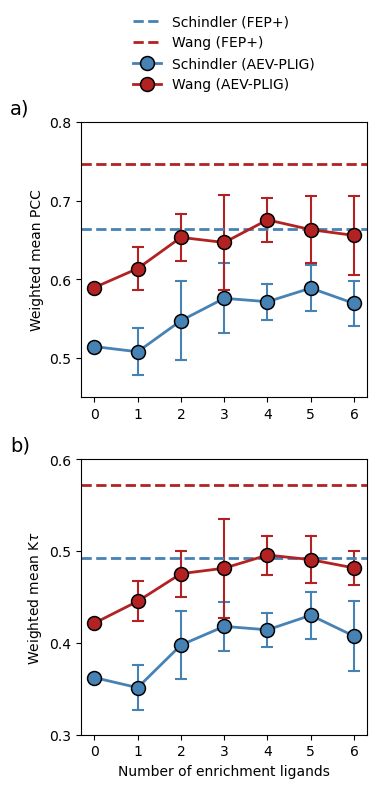

In [17]:
plot_lineplot_with_error_bars(
    df_merck,
    df_schro,
    "Schindler (AEV-PLIG)", "Wang (AEV-PLIG)",
    [merck_fep_wpcc, merck_fep_wktau],
    [schro_fep_wpcc, schro_fep_wktau],
    "Schindler (FEP+)", "Wang (FEP+)",
    [0.45, 0.8],
    [0.3, 0.6],
    [0.5, 0.6, 0.7, 0.8],
    [0.3, 0.4, 0.5, 0.6],
    xlabel="Number of enrichment ligands",
    outpath="figure5.pdf"
)

#### Figure 6: AEV-PLIG performance vs FEP

In [19]:
def plot_bars_comparison(df1, df2, df3, column1, column2, xlabel='', y1_label='', y2_label='', y1_lim=(0,1), y2_lim=(0,2), outpath=None):
    
    labels = df1.index
    x = [x for x in range(8)] + [x+9 for x in range(8)]
    
    bar_width = 0.23

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,6), sharex=True, constrained_layout=True)
    
    bars1_1 = ax1.bar(x, df1[column1], bar_width, label='AEV-PLIG', edgecolor='black')
    bars1_2 = ax1.bar([i + bar_width for i in x], df2[column1], bar_width, label='AEV-PLIG (enriched)', edgecolor='black')
    bars1_3 = ax1.bar([i + 2*bar_width for i in x], df3[column1], bar_width, label='FEP', edgecolor='black')

    bars2_1 = ax2.bar(x, df1[column2], bar_width, label='AEV-PLIG', edgecolor='black')
    bars2_2 = ax2.bar([i + bar_width for i in x], df2[column2], bar_width, label='AEV-PLIG (enriched)', edgecolor='black')
    bars2_3 = ax2.bar([i + 2*bar_width for i in x], df3[column2], bar_width, label='FEP', edgecolor='black')

    ax1.set_ylim(y1_lim)
    ax2.set_ylim(y2_lim)

    ax2.set_xlabel(xlabel, labelpad=1)
    ax1.set_ylabel(y1_label)
    ax2.set_ylabel(y2_label)

    ax1.set_xticks([i + bar_width for i in x])
    ax2.set_xticks([i + bar_width for i in x])
    ax2.set_xticklabels(labels)
    ax1.legend(ncol=3, frameon=False, loc='upper left', bbox_to_anchor=(0.24, 1.25))
    
    plt.xticks(rotation=90)

    # Adding horizontal lines and annotations
    ax2.axhline(y=-0.74, xmin=0.05, xmax=0.45, color='black', clip_on=False)
    ax2.axhline(y=-0.74, xmin=0.55, xmax=0.95, color='black', clip_on=False)
    ax2.annotate('Schindler FEP', xy=(0.25, -0.56), 
                xycoords='axes fraction', ha='center', va='center')
    ax2.annotate('Wang FEP', xy=(0.75, -0.56), 
                xycoords='axes fraction', ha='center', va='center')


    if outpath:
        plt.tight_layout(pad=1)
        plt.savefig(outpath, dpi=500)

In [20]:
def get_performance_df(results, preds_col, truth_col, targets):
    results['pred'] = results[preds_col]
    results['truth'] = results[truth_col]
    
    logs = []
    for target in targets:
        subset = results[results["Target"] == target]
        logs.append([target, pearsonr(subset["pred"], subset["truth"])[0], kendalltau(subset["pred"], subset["truth"])[0], rmse(subset["pred"], subset["truth"]), len(subset)])

    performance = pd.DataFrame(logs, columns=["target","pearson_r","kendall_tau","rmse","sample_size"])
    performance.set_index("target", inplace=True)

    return performance

In [23]:
results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random1_predictions.csv')
merck_ids_1 = list(results["graph_id"])
enriched_merck_1 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
enriched_merck_1.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
enriched_merck_1 = enriched_merck_1.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random2_predictions.csv')
merck_ids_2 = list(results["graph_id"])
enriched_merck_2 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
enriched_merck_2.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
enriched_merck_2 = enriched_merck_2.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random3_predictions.csv')
merck_ids_3 = list(results["graph_id"])
enriched_merck_3 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
enriched_merck_3.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
enriched_merck_3 = enriched_merck_3.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random4_predictions.csv')
merck_ids_4 = list(results["graph_id"])
enriched_merck_4 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
enriched_merck_4.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
enriched_merck_4 = enriched_merck_4.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_enrich4_random5_predictions.csv')
merck_ids_5 = list(results["graph_id"])
enriched_merck_5 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
enriched_merck_5.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
enriched_merck_5 = enriched_merck_5.reset_index().rename(columns={"index":"target"})


In [25]:
results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random1_predictions.csv')
schro_ids_1 = list(results["graph_id"])
enriched_schro_1 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
enriched_schro_1.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
enriched_schro_1 = enriched_schro_1.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random2_predictions.csv')
schro_ids_2 = list(results["graph_id"])
enriched_schro_2 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
enriched_schro_2.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
enriched_schro_2 = enriched_schro_2.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random3_predictions.csv')
schro_ids_3 = list(results["graph_id"])
enriched_schro_3 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
enriched_schro_3.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
enriched_schro_3 = enriched_schro_3.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random4_predictions.csv')
schro_ids_4 = list(results["graph_id"])
enriched_schro_4 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
enriched_schro_4.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
enriched_schro_4 = enriched_schro_4.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_enrich4_random1_predictions.csv')
schro_ids_5 = list(results["graph_id"])
enriched_schro_5 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
enriched_schro_5.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
enriched_schro_5 = enriched_schro_5.reset_index().rename(columns={"index":"target"})


In [30]:
results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(merck_ids_1)]
baseline_merck_1 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
baseline_merck_1.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
baseline_merck_1 = baseline_merck_1.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(merck_ids_2)]
baseline_merck_2 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
baseline_merck_2.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
baseline_merck_2 = baseline_merck_2.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(merck_ids_3)]
baseline_merck_3 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
baseline_merck_3.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
baseline_merck_3 = baseline_merck_3.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(merck_ids_4)]
baseline_merck_4 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
baseline_merck_4.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
baseline_merck_4 = baseline_merck_4.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(merck_ids_5)]
baseline_merck_5 = get_performance_df(results, 'preds', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
baseline_merck_5.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
baseline_merck_5 = baseline_merck_5.reset_index().rename(columns={"index":"target"})


In [33]:
results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(schro_ids_1)]
baseline_schro_1 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
baseline_schro_1.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
baseline_schro_1 = baseline_schro_1.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(schro_ids_2)]
baseline_schro_2 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
baseline_schro_2.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
baseline_schro_2 = baseline_schro_2.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(schro_ids_3)]
baseline_schro_3 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
baseline_schro_3.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
baseline_schro_3 = baseline_schro_3.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(schro_ids_4)]
baseline_schro_4 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
baseline_schro_4.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
baseline_schro_4 = baseline_schro_4.reset_index().rename(columns={"index":"target"})

results = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim90_predictions.csv')
results = results[results["graph_id"].isin(schro_ids_5)]
baseline_schro_5 = get_performance_df(results, 'preds', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
baseline_schro_5.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
baseline_schro_5 = baseline_schro_5.reset_index().rename(columns={"index":"target"})

In [36]:
results = pd.read_csv("../data/fep/merck_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(merck_ids_1)]
fep_merck_1 = get_performance_df(results, 'Pred. ΔG', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
fep_merck_1.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
fep_merck_1 = fep_merck_1.reset_index().rename(columns={"index":"target"})

results = pd.read_csv("../data/fep/merck_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(merck_ids_2)]
fep_merck_2 = get_performance_df(results, 'Pred. ΔG', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
fep_merck_2.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
fep_merck_2 = fep_merck_2.reset_index().rename(columns={"index":"target"})

results = pd.read_csv("../data/fep/merck_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(merck_ids_3)]
fep_merck_3 = get_performance_df(results, 'Pred. ΔG', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
fep_merck_3.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
fep_merck_3 = fep_merck_3.reset_index().rename(columns={"index":"target"})

results = pd.read_csv("../data/fep/merck_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(merck_ids_4)]
fep_merck_4 = get_performance_df(results, 'Pred. ΔG', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
fep_merck_4.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
fep_merck_4 = fep_merck_4.reset_index().rename(columns={"index":"target"})

results = pd.read_csv("../data/fep/merck_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(merck_ids_5)]
fep_merck_5 = get_performance_df(results, 'Pred. ΔG', 'Exp. ΔG', ["cdk8","cmet","eg5","hif2a","pfkfb3","shp2","syk","tnks2"])
fep_merck_5.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']
fep_merck_5 = fep_merck_5.reset_index().rename(columns={"index":"target"})

In [37]:
results = pd.read_csv("../data/fep/schrodinger_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(schro_ids_1)]
fep_schro_1 = get_performance_df(results, 'Pred. dG', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
fep_schro_1.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
fep_schro_1 = fep_schro_1.reset_index().rename(columns={"index":"target"})

results = pd.read_csv("../data/fep/schrodinger_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(schro_ids_2)]
fep_schro_2 = get_performance_df(results, 'Pred. dG', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
fep_schro_2.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
fep_schro_2 = fep_schro_2.reset_index().rename(columns={"index":"target"})

results = pd.read_csv("../data/fep/schrodinger_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(schro_ids_3)]
fep_schro_3 = get_performance_df(results, 'Pred. dG', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
fep_schro_3.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
fep_schro_3 = fep_schro_3.reset_index().rename(columns={"index":"target"})

results = pd.read_csv("../data/fep/schrodinger_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(schro_ids_4)]
fep_schro_4 = get_performance_df(results, 'Pred. dG', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
fep_schro_4.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
fep_schro_4 = fep_schro_4.reset_index().rename(columns={"index":"target"})

results = pd.read_csv("../data/fep/schrodinger_graphs.csv", index_col=0)
results = results[results["graph_id"].isin(schro_ids_5)]
fep_schro_5 = get_performance_df(results, 'Pred. dG', 'Exp. dG', ["Bace","CDK2","Jnk1","MCL1","p38","PTP1B","Thrombin","Tyk2"])
fep_schro_5.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']
fep_schro_5 = fep_schro_5.reset_index().rename(columns={"index":"target"})

In [38]:
enriched_schro = pd.concat([enriched_schro_1, enriched_schro_2, enriched_schro_3, enriched_schro_4, enriched_schro_5]).groupby("target").mean()
print(enriched_schro)
enriched_merck = pd.concat([enriched_merck_1, enriched_merck_2, enriched_merck_3, enriched_merck_4, enriched_merck_5]).groupby("target").mean()
print(enriched_merck)

baseline_schro = pd.concat([baseline_schro_1, baseline_schro_2, baseline_schro_3, baseline_schro_4, baseline_schro_5]).groupby("target").mean()
print(baseline_schro)
baseline_merck = pd.concat([baseline_merck_1, baseline_merck_2, baseline_merck_3, baseline_merck_4, baseline_merck_5]).groupby("target").mean()
print(baseline_merck)

fep_schro = pd.concat([fep_schro_1, fep_schro_2, fep_schro_3, fep_schro_4, fep_schro_5]).groupby("target").mean()
print(fep_schro)
fep_merck = pd.concat([fep_merck_1, fep_merck_2, fep_merck_3, fep_merck_4, fep_merck_5]).groupby("target").mean()
print(fep_merck)

          pearson_r  kendall_tau      rmse  sample_size
target                                                 
BACE       0.812418     0.550556  0.541497         32.0
CDK2       0.869188     0.721212  0.771118         12.0
JNK1       0.459654     0.335058  0.798538         17.0
MCL1       0.655398     0.469457  0.838926         38.0
PTP1B      0.788128     0.619215  0.916170         19.0
Thrombin   0.824979     0.485714  0.487870          7.0
Tyk2       0.628370     0.424242  1.153982         12.0
p38        0.588632     0.486262  0.874708         30.0
        pearson_r  kendall_tau      rmse  sample_size
target                                               
CDK8     0.807063     0.701694  1.028792         29.0
Eg5      0.733890     0.423401  1.136373         24.0
HIF-2a   0.390916     0.308382  1.054771         38.0
PFKFB3   0.315644     0.222857  1.212290         36.0
SHP2     0.443928     0.264069  1.232222         22.0
SYK      0.624212     0.440366  0.750428         40.0
TNKS2   

/var/folders/n0/jnvj1pls2_5_j5b80078qmx40000gn/T/ipykernel_74614/106460807.py:42: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout(pad=1)


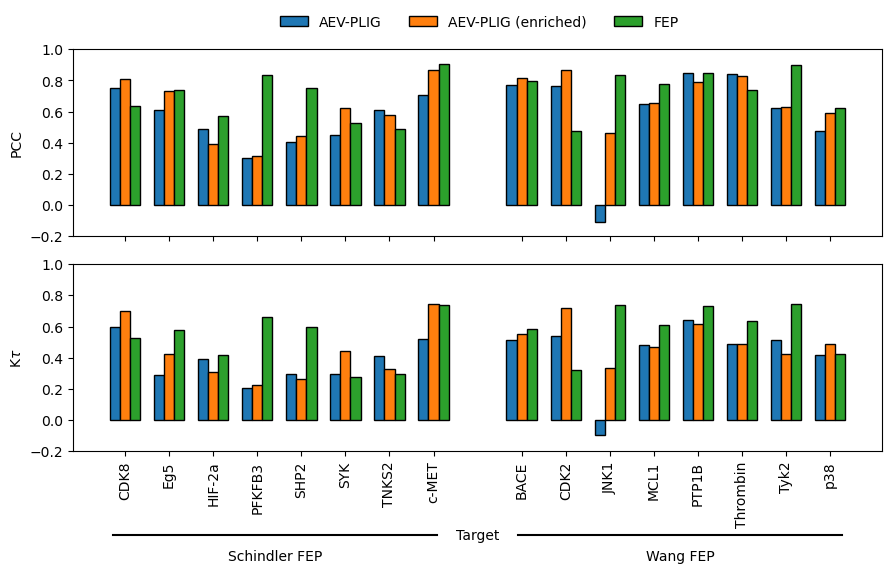

In [39]:
plot_bars_comparison(pd.concat([baseline_merck, baseline_schro]), pd.concat([enriched_merck, enriched_schro]), pd.concat([fep_merck,fep_schro]),"pearson_r", "kendall_tau", xlabel='Target', y1_label='PCC', y2_label=r"K$\tau$", y1_lim=(-0.2,1), y2_lim=(-0.2, 1), outpath='./figure6.pdf')